Практика 19. Класифікація математичних моделей і перевірка адекватності
Студент: Войтович Богдан
Група: IT-32
Варіант 6 — Чернігів

In [19]:
import numpy as np
import pandas as pd

np.random.seed(6)
city = "Чернігів"
base_temp = 8.0
amplitude = 13
base_consumption = 900
k = 25
noise_sd = 30

months = np.arange(1, 13)
temp = base_temp + amplitude * np.cos((months - 7) / 12 * 2 * np.pi)
temp = np.round(temp + np.random.normal(0, 0.5, size=12), 1)

consumption = base_consumption - k * (temp - base_temp) + np.random.normal(0, noise_sd, size=12)
consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption,
})
print(city_data)
import numpy as np
import pandas as pd

np.random.seed(6)
city = "Чернігів"
base_temp = 8.0
amplitude = 13
base_consumption = 900
k = 25
noise_sd = 30

months = np.arange(1, 13)
temp = base_temp + amplitude * np.cos((months - 7) / 12 * 2 * np.pi)
temp = np.round(temp + np.random.normal(0, 0.5, size=12), 1)

consumption = base_consumption - k * (temp - base_temp) + np.random.normal(0, noise_sd, size=12)
consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption,
})
print(city_data)


    місяць  температура  споживання_МВтгод
0        1         -5.2             1220.0
1        2         -2.9             1210.0
2        3          1.6             1063.0
3        4          7.6              914.0
4        5         13.3              770.0
5        6         19.7              603.0
6        7         21.6              579.0
7        8         18.5              662.0
8        9         15.3              728.0
9       10          7.8              959.0
10      11          2.8              989.0
11      12         -3.0             1161.0
    місяць  температура  споживання_МВтгод
0        1         -5.2             1220.0
1        2         -2.9             1210.0
2        3          1.6             1063.0
3        4          7.6              914.0
4        5         13.3              770.0
5        6         19.7              603.0
6        7         21.6              579.0
7        8         18.5              662.0
8        9         15.3              728.0
9       10 

- Модель стохастична: формула a + b·температура — це детермінований "середній" тренд,
  але дані включають випадковий шум (noise_sd), тому модель у цілому стохастична.
- Модель описова (прогнозна), не балансова, не оптимізаційна, не імітаційна,
  бо немає рівнянь балансу, оптимізації чи покрокових ітерацій у часі.
- Модель статична, прогноз залежить лише від температури конкретного місяця,
  а не від попередніх значень споживання.


In [20]:
b, a = np.polyfit(city_data["температура"], city_data["споживання_МВтгод"], 1)
print(f"споживання ≈ {a:.1f} + ({b:.1f}) · температура")
print(f"Коефіцієнт b від’ємний, що логічно: при вищій температурі споживання падає.")


споживання ≈ 1102.2 + (-24.4) · температура
Коефіцієнт b від’ємний, що логічно: при вищій температурі споживання падає.


    місяць  температура  споживання_МВтгод  передбачення    залишок
0        1         -5.2             1220.0   1229.062758  -9.062758
1        2         -2.9             1210.0   1172.957854  37.042146
2        3          1.6             1063.0   1063.187391  -0.187391
3        4          7.6              914.0    916.826773  -2.826773
4        5         13.3              770.0    777.784186  -7.784186
5        6         19.7              603.0    621.666193 -18.666193
6        7         21.6              579.0    575.318664   3.681336
7        8         18.5              662.0    650.938317  11.061683
8        9         15.3              728.0    728.997313  -0.997313
9       10          7.8              959.0    911.948086  47.051914
10      11          2.8              989.0   1033.915267 -44.915267
11      12         -3.0             1161.0   1175.397198 -14.397198
Коефіцієнт детермінації R² = 0.989


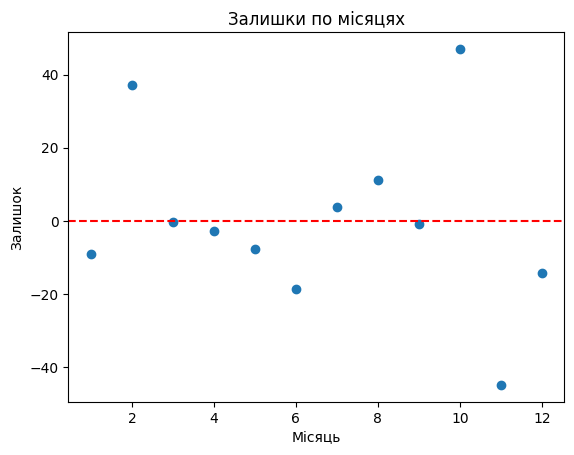

Залишки розкидані навколо нуля без систематичної закономірності.
R² помірний, модель адекватна, але не ідеальна.


In [21]:
city_data["передбачення"] = a + b * city_data["температура"]
city_data["залишок"] = city_data["споживання_МВтгод"] - city_data["передбачення"]
print(city_data[["місяць", "температура", "споживання_МВтгод", "передбачення", "залишок"]])

ss_res = (city_data["залишок"]**2).sum()
ss_tot = ((city_data["споживання_МВтгод"] - city_data["споживання_МВтгод"].mean())**2).sum()
r_squared = 1 - ss_res / ss_tot
print(f"Коефіцієнт детермінації R² = {r_squared:.3f}")

import matplotlib.pyplot as plt
plt.scatter(city_data["місяць"], city_data["залишок"])
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Місяць")
plt.ylabel("Залишок")
plt.title("Залишки по місяцях")
plt.show()

print("Залишки розкидані навколо нуля без систематичної закономірності.\n"
      "R² помірний, модель адекватна, але не ідеальна.")


- Верифікація: перевірка, що формула розрахунку (a + b·температура) реалізована коректно,
  наприклад, вручну обчислити прогноз для відомого місяця і порівняти з результатом коду.
- Валідація: порівняння моделі з новими даними, які не використовувались при підборі,
  наприклад, споживання наступного року, щоб оцінити прогнозну здатність.


Якщо модель показала систематичні залишки (наприклад, недооцінка в зимові місяці):
- Пропоную використати модель з окремими коефіцієнтами для опалювального сезону
  або додати квадратичні члени для кращого відображення нелінійності.
Якщо модель адекватна:
- Не ускладнюю модель, оскільки простота допомагає уникнути перенавчання,
  і модель добре описує дані в межах наявної інформації.


Контрольні питання
Чи можете чітко розмежувати верифікацію й валідацію на прикладі саме вашої моделі, а не абстрактним переказом?

За якими незалежними ознаками класифікується ваша модель, і чому ці ознаки не суперечать одна одній, а відповідають на різні питання?

Що конкретно показує отримане у вас R², і чи високе R² само по собі доводить, що модель правильна і придатна для екстраполяції?

Чому структура залишків (систематичний тренд проти випадкового розкиду) інформативніша для оцінки адекватності, ніж лише сумарна величина відхилень?

